# Drawdowns, Sharpe Ratios and Risk-Adjusted Returns

*Analyst Desk · The Analytical Investor · Year 1, Month 9*

**Read the article:** [Drawdowns, Sharpe Ratios and Risk-Adjusted Returns](https://analytical-investor.blog/?p=1023)

How much can a track record tell you? The standard error of a Sharpe ratio, and a simulation of what five-year records look like for a manager with a true Sharpe of 0.5.

> Run locally with `pip install -e ".[notebooks]"` from the repo root, then open this notebook in Jupyter. All data is simulated with fixed seeds, so every number matches the article.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9, 5), "axes.grid": True, "grid.alpha": 0.3})

## The standard error formula

In [2]:
from analytical_investor.risk import sharpe_standard_error
for years in (3, 5, 10, 20, 40):
    se = sharpe_standard_error(0.5, years)
    print(f"{years:>2} years: SE {se:.2f}, 95% CI {0.5 - 1.96*se:+.2f} to {0.5 + 1.96*se:+.2f}")

 3 years: SE 0.61, 95% CI -0.70 to +1.70
 5 years: SE 0.47, 95% CI -0.43 to +1.43
10 years: SE 0.34, 95% CI -0.16 to +1.16
20 years: SE 0.24, 95% CI +0.04 to +0.96
40 years: SE 0.17, 95% CI +0.17 to +0.83


## Simulated five-year track records, true Sharpe 0.5

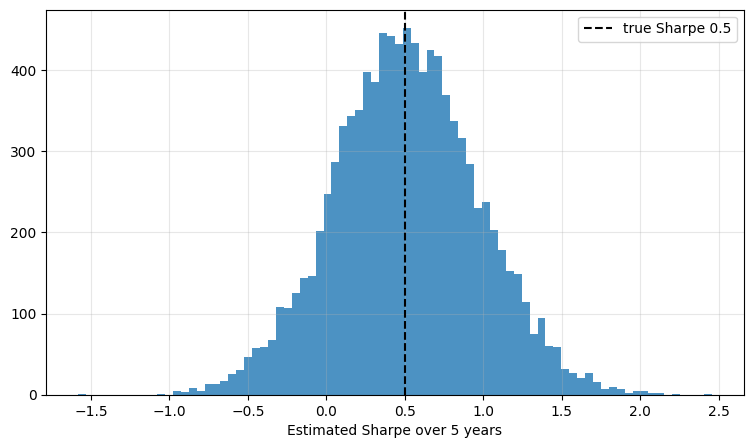

Share of records showing a Sharpe below zero: 13%
Share showing above 1.0: 14%


In [3]:
rng = np.random.default_rng(9)
monthly = rng.normal(0.5 * 0.15 / 12, 0.15 / np.sqrt(12), (10_000, 60))
est = monthly.mean(axis=1) / monthly.std(axis=1, ddof=1) * np.sqrt(12)
plt.hist(est, bins=80, alpha=0.8)
plt.axvline(0.5, color="k", ls="--", label="true Sharpe 0.5")
plt.xlabel("Estimated Sharpe over 5 years"); plt.legend(); plt.show()
print(f"Share of records showing a Sharpe below zero: {(est < 0).mean():.0%}")
print(f"Share showing above 1.0: {(est > 1).mean():.0%}")